<a href="https://colab.research.google.com/github/Padmini-c4/DataScience_Task/blob/main/Task2_Logistic_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Heart Disease Prediction

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

Data preparation

In [2]:
df=pd.read_csv("/content/heart.csv")
df.head( )

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Data Cleaning

In [3]:
# remove duplicate rows
df.drop_duplicates(inplace=True)

In [4]:
# identifying null values
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0


In [5]:
#drop unwanted columns in the datasets
df.drop("Unnamed: 0",axis=1,inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [6]:
#rename talach to heart_rate and trestbps to blood_pressure
df.rename(columns={"trestbps":"blood_pressure"},inplace=True)
df.rename(columns={"thalach":"heart_rate"},inplace=True)
df

,age,sex,cp,blood_pressure,chol,fbs,restecg,heart_rate,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [7]:
df["oldpeak"].unique()

array([2.3, 3.5, 1.4, 0.8, 0.6, 0.4, 1.3, 0. , 0.5, 1.6, 1.2, 0.2, 1.8,
       1. , 2.6, 1.5, 3. , 2.4, 0.1, 1.9, 4.2, 1.1, 2. , 0.7, 0.3, 0.9,
       3.6, 3.1, 3.2, 2.5, 2.2, 2.8, 3.4, 6.2, 4. , 5.6, 2.9, 2.1, 3.8,
       4.4])

EDA

<Axes: xlabel='sex', ylabel='count'>

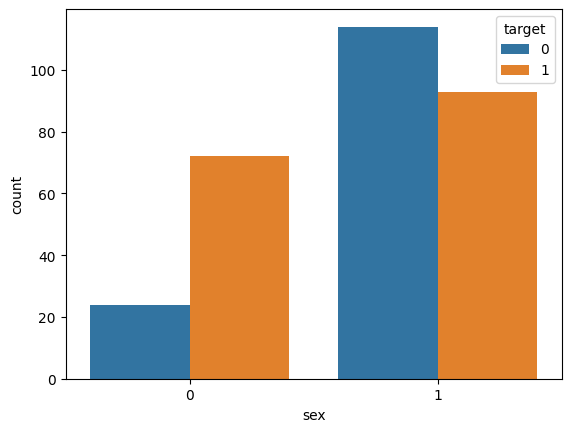

In [8]:
#sex vs target
sns.countplot(x="sex",hue="target",data=df)
# sns.histplot(x="sex",hue="target",data=df)



*   Heart disease cases are higher in males compared to females.

*  Females show less heart disease cases in the dataset.



<Axes: xlabel='blood_pressure', ylabel='Count'>

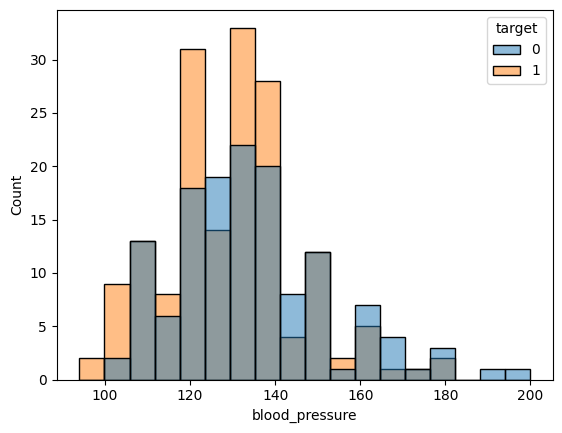

In [9]:
#check in which range of bp heart diseases are more
#blood_pressure vs target
sns.histplot(x="blood_pressure",hue="target",data=df)



*   Heart disease cases are more common when blood pressure is around 120–140.
*   Very low and very high blood pressure ranges show less heart disease cases.


<Axes: xlabel='heart_rate', ylabel='Count'>

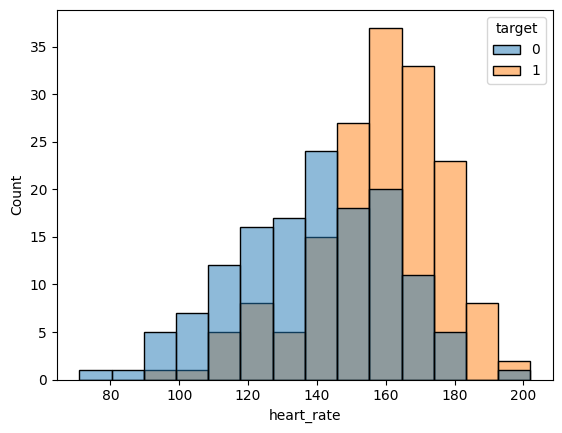

In [10]:
#check for which heart rate heart disease is more
#heart_rate vs target
sns.histplot(x="heart_rate",hue="target",data=df)

*   Heart disease cases are
more common when the heart rate is around 150–170 bpm.
*   Lower heart rate values show less heart disease cases compared to high.



<Axes: xlabel='age', ylabel='Count'>

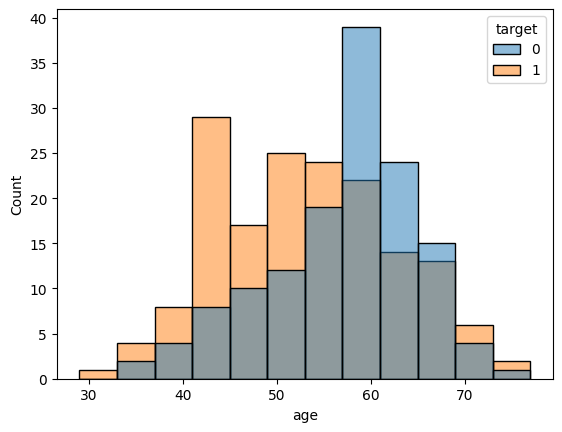

In [11]:
#which age group have more heart disease
sns.histplot(x="age",hue="target",data=df)


*   Heart disease is more common in the middle age group (45–60 years).
*   Very young and very old age groups show less cases.



Model Training

In [12]:
# divide input and output columns
X = df.drop("target",axis=1)
y = df.target

In [13]:
# split the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [15]:
# model training
model = LogisticRegression()
model.fit(Xtrain,ytrain)

LogisticRegression()

Prediction

In [16]:
# predict the model
ypred = model.predict(Xtest)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1])

In [17]:
# print confusion matrix
confusion_matrix(ytest,ypred)

array([[32,  9],
       [ 8, 42]])

In [18]:
# print classification report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



In [19]:
# Testing and training efficiency
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.8726415094339622
Testing Eff:  0.8131868131868132
